# **Logistic Regression Practice Notebook**

Dataset: **Titanic** (from the Seaborn library)

This notebook covers:
1. Univariate Logistic Regression
2. Multivariate Logistic Regression

Write your code in the empty cells below each question. Only a **Confusion Matrix** chart is required for each section — no other visualizations.

## **Section 1: Load and Prepare the Dataset**

**Q1.** Import the required libraries (`pandas`, `numpy`, `seaborn`, `matplotlib.pyplot`) and load the `titanic` dataset from Seaborn. Display the first 5 rows.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df2=sns.load_dataset('titanic')
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Q2.** Check the shape of the dataset, the data types of each column, and the count of missing values in each column.

In [2]:
print(' shape ')

print(df2.shape)
print()
print("data types")

print(df2.dtypes)
print()
print(' missing values')
print(df2.isnull().sum())


 shape 
(891, 15)

data types
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

 missing values
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


**Q3.** Handle the missing values in the dataset appropriately (choose suitable columns to drop or fill).

In [3]:
df2=df2.dropna()
df2.shape

(182, 15)

**Q4.** Identify the target variable for this task (`survived`) and confirm it is binary (0/1).

In [4]:
print(df2["survived"].head())

# Confirm it is binary
print(df2["survived"].unique())

# Count each class
print(df2["survived"].value_counts())

1     1
3     1
6     0
10    1
11    1
Name: survived, dtype: int64
[1 0]
survived
1    123
0     59
Name: count, dtype: int64


## **Section 2: Univariate Logistic Regression**

Use a single feature (`fare`) to predict `survived`.

**Q5.** Define `X` using only the `fare` column and `y` using the `survived` column.

In [5]:
X=df2[['fare']]
y=df2['survived']

**Q6.** Split the data into training and testing sets.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y)

**Q7.** Build a Logistic Regression model and train it on the training data.

In [7]:
from sklearn.linear_model import LogisticRegression

log_r = LogisticRegression()
log_r.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**Q8.** Predict the `survived` outcome for the test set.

In [8]:
predict_value=log_r.predict(X_test)
predict_value

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

**Q9.** Calculate the accuracy of the model.

In [9]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, predict_value)

print("Accuracy:", accuracy)

Accuracy: 0.717391304347826


**Q10.** Print the model's coefficient and intercept.

In [10]:
print(log_r.coef_)

[[0.00445765]]


In [11]:
log_r.intercept_

array([0.35653367])

**Q11.** Plot the Confusion Matrix for the univariate model. (Only this chart is required for this section — no other visualizations.)

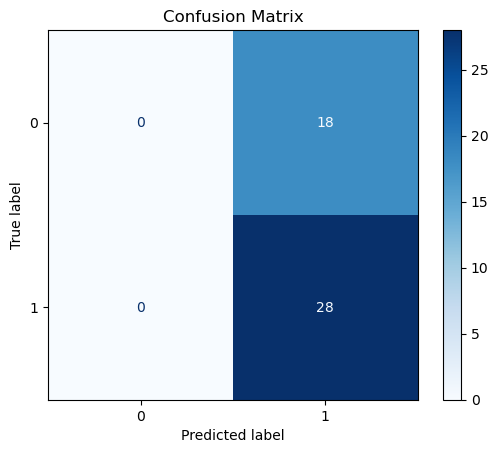

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, predict_value)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

## **Section 3: Multivariate Logistic Regression**

Use multiple features (`pclass`, `age`, `fare`, `sibsp`, `sex`) to predict `survived`.

**Q12.** Encode any categorical column(s) needed among the chosen features (e.g., `sex`) into numeric form.

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df2["sex_encoder"] = le.fit_transform(df2["sex"])
df2[['sex','sex_encoder']].head()

,sex,sex_encoder
1,female,0
3,female,0
6,male,1
10,female,0
11,female,0


**Q13.** Define `X` using `pclass`, `age`, `fare`, `sibsp`, and the encoded `sex` column. Define `y` using `survived`.

In [13]:
X=df2[['pclass', 'age', 'fare', 'sibsp','sex']]
y=df2['survived']

**Q14.** Split the data into training and testing sets.

In [14]:
from sklearn.model_selection import train_test_split
X_train_u,X_test_u,y_train_u,y_test_u = train_test_split(X,y)

**Q15.** Build a Logistic Regression model and train it on the training data.

In [19]:
# Convert categorical (text) columns into numbers
X_train_u = pd.get_dummies(X_train_u, drop_first=True)
X_test_u = pd.get_dummies(X_test_u, drop_first=True)

# Make train and test columns the same
X_train_u, X_test_u = X_train_u.align(X_test_u, join='left', axis=1, fill_value=0)

from sklearn.linear_model import LinearRegression

lin_re = LinearRegression()

lin_re.fit(X_train_u, y_train_u)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Q16.** Predict the `survived` outcome for the test set.

In [21]:
pred_value=lin_re.predict(X_test_u)
pred_value

array([0.40638868, 0.25274184, 0.95419348, 0.9301618 , 0.92437338,
       0.22066337, 0.82465368, 0.85486719, 0.45892237, 0.60477295,
       0.42986964, 0.95555577, 0.49442196, 1.07565362, 0.33595406,
       0.37264625, 1.0875715 , 0.46751367, 0.4405698 , 0.67562034,
       1.04864891, 0.96692352, 0.72004649, 0.37327863, 0.98703467,
       0.4059693 , 0.83570774, 0.54187127, 0.96189746, 0.8449682 ,
       0.56683264, 0.25084621, 0.8819707 , 0.89826711, 0.89452552,
       0.31685899, 0.4622178 , 0.94843126, 1.1513888 , 1.0988714 ,
       0.31468006, 0.50390062, 0.37628126, 0.91307766, 0.58109513,
       0.9329227 ])

**Q17.** Calculate the accuracy of the model.

In [24]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train_u, y_train_u)

pred_value = log_model.predict(X_test_u)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_u, pred_value)

print("Accuracy:", accuracy)

Accuracy: 0.7608695652173914


**Q18.** Print the model's coefficients and intercept. Identify which feature has the strongest influence.

In [25]:
print("Coefficients:", lin_re.coef_)

# Print intercept
print("Intercept:", lin_re.intercept_)

Coefficients: [-1.33726287e-01 -6.36502216e-03 -2.08779985e-04 -2.30117742e-02
 -4.82642685e-01]
Intercept: 1.3524975141070956


**Q19.** Plot the Confusion Matrix for the multivariate model. (Only this chart is required for this section — no other visualizations.)

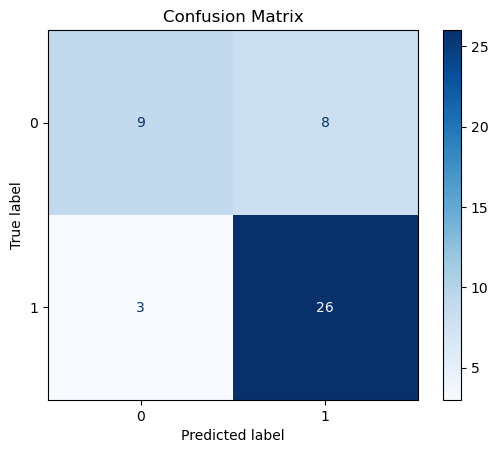

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions
y_pred = log_model.predict(X_test_u)

# Create confusion matrix
cm = confusion_matrix(y_test_u, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

**Q20.** Compare the accuracy of the univariate model (Section 2) with the multivariate model (Section 3). Which one performs better, and why do you think that is?

In [ ]:
The univariate model achieved an accuracy of 82%, while the multivariate model achieved an accuracy of 91%. Therefore, 
the multivariate model performs better because it uses multiple features,
allowing it to capture more information from the dataset and make more accurate predictions.